# 1. 군집화(Clustering)  
군집화는 **비지도 학습(Unsupervised Learning)**의 일종으로, 데이터의 라벨 정보 없이 유사한 성질을 가진 데이터끼리 묶는 방법이다.

| 항목      | 설명                                         |
| ------- | ------------------------------------------ |
| 학습 방식   | 라벨이 없는 데이터를 기반으로 학습 (비지도 학습)               |
| 목적      | 유사한 데이터끼리 묶어서 그룹을 형성                       |
| 주요 알고리즘 | K-Means,평균 이동 (Mean Shift), GMM, DBSCAN등 |
| 활용 분야   |  고객 분류, 이미지 분석, 문서 분류 , 이상치 탐지 등            |


# 2. 군집화 알고리즘

| 알고리즘                   | 주요 개념    | 처리 과정                                                                                       | 장점                       | 단점                       |
| ---------------------- | -------- | ------------------------------------------------------------------------------------------- | ------------------------ | ------------------------ |
| **KMeans**             | 중심 기반    | ① 군집 수(K) 설정<br>② 초기 중심 선택<br>③ 샘플 할당<br>④ 중심 업데이트<br>⑤ 수렴 시 종료                             | 빠름, 대규모 데이터 적합           | 초기 중심 민감, 비선형 구조 미흡      |
| **평균 이동 (Mean Shift)** | 모드 탐색 기반 | ① 각 샘플을 중심으로 커널 밀도 계산<br>② 밀도 높은 방향으로 중심 이동<br>③ 수렴 시 모드(peak) 판단<br>④ 가까운 모드들 병합하여 군집 형성   | 군집 수 자동 결정, 복잡한 구조 탐지 가능 | 계산 비용 큼, 고차원 데이터에서 느림    |
| **GMM**                | 확률 기반    | ① 군집 수(K) 설정<br>② 초기 파라미터 설정<br>③ E-step: 소속 확률 계산<br>④ M-step: 가우시안 파라미터 업데이트<br>⑤ 수렴 시 종료 | 소속 확률 제공, 타원형 군집 탐지 가능   | 초기값 민감, 수렴 느릴 수 있음, K 필요 |
| **DBSCAN**             | 밀도 기반    | ① 반경 ε 설정<br>② 이웃 개수 ≥ MinPts 확인<br>③ 핵심점 선정<br>④ 이웃 연결 확장<br>⑤ 잡음 구분                       | 이상치 강건, 군집 수 자동 결정 가능    | 희소데이터 부적합, 파라미터 민감       |


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# 데이터 불러오기
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 정답 라벨 (평가용)

# 데이터 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 시각화를 위한 차원 축소 (2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(X_pca.shape)


(569, 2)


## 3. KMeans 클러스터링
- K: 군집의 수 (사용자가 지정)
- 각 데이터를 K개의 중심점(Centroid)에 할당하고, 반복적으로 중심을 업데이트하면서 군집을 형성
- 거리 기반 알고리즘 (보통 유클리드 거리 사용)

| 옵션                 | 기본값           | 설명                                                                                 |
| ------------------ | ------------- | ---------------------------------------------------------------------------------- |
| **`n_clusters`**   | 8             | 생성할 군집(클러스터)의 수 `K`를 지정합니다.                                                        |
| **`init`**         | `'k-means++'` | 초기 중심점 선택 방법<br> `'k-means++'`: 좋은 성능의 기본값<br> `'random'`: 무작위 선택<br> 또는 사용자 지정 배열 |
| **`n_init`**       | 10            | 서로 다른 초기 중심점 설정으로 몇 번 알고리즘을 실행할지 지정. 최적의 결과 중 하나를 선택                               |
| **`max_iter`**     | 300           | 단일 실행에서 군집 중심을 업데이트할 최대 반복 횟수                                                      |
| **`tol`**          | 1e-4          | 수렴 판정 기준인 중심 변화 허용 오차 (작을수록 더 정확하게 수렴)                                             |
| **`random_state`** | `None`        | 초기 중심점 선택에 대한 랜덤 시드. 결과 재현에 사용                                                     |
| **`algorithm`**    | `'lloyd'`     | 사용 알고리즘 종류 <br> `'lloyd'`: 기본 알고리즘 <br> `'elkan'`: 유클리디안 거리에서 더 빠름 (고차원에서는 느림)     |
| **`verbose`**      | 0             | 학습 과정의 로그를 출력할지 여부 (1이면 출력됨)                                                       |
| **`copy_x`**       | `True`        | 입력 데이터를 복사해서 사용하는지 여부 (False면 원본 데이터에 영향 가능)                                       |




[init 파라미터]
- init 파라미터는 **초기 중심점(centroid)**을 어떻게 선택할지를 결정


  | 값             | 설명                                                                            |
  | ------------- | ----------------------------------------------------------------------------- |
  | `'k-means++'` | **기본값**. 군집 간 거리를 고려해 초기 중심을 뽑아 **빠르고 안정적인 수렴**을 유도함. 거의 모든 경우에 추천됨.          |
  | `'random'`    | **완전히 무작위**로 중심을 선택. 성능이 불안정할 수 있으며 `n_init` 값을 높게 설정해 여러 번 실행하는 것이 필요함.      |
  | 배열 (ndarray)  | 사용자 정의 초기 중심값 배열을 직접 지정할 수 있음. 형식: `(n_clusters, n_features)` 형태의 `numpy` 배열. |
  | `callable`    | 함수 형태로 직접 초기화 로직을 제공할 수도 있음 (고급 사용 시).                                        |

- k-means++ 사용 (기본)
```
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
kmeans.fit(X_scaled)
```

- random 사용
```
kmeans = KMeans(n_clusters=3, init='random', random_state=42)
kmeans.fit(X_scaled)
```
> ※ random은 수렴이 느리거나 나쁜 로컬 최솟값에 빠질 수 있으므로 보통 n_init=10~20 이상을 권장한다.

- 사용자 지정 중심점 배열
```
# 사용자 지정 중심점 배열
import numpy as np
# 예시로 첫 3개의 데이터를 초기 중심으로 지정
init_centers = X_scaled[:3]  # shape: (3, n_features)
kmeans = KMeans(n_clusters=3, init=init_centers, n_init=1)
kmeans.fit(X_scaled)
```
> ※ 이 경우 n_init=1로 반드시 설정해야 한다. (init이 배열일 경우 자동 반복 초기화 안 됨)


[algorithm 파라미터]  
1) 'lloyd' 알고리즘 (기본)  
① 각 포인트를 가장 가까운 중심에 할당  
② 각 군집의 평균으로 중심을 재계산  
③ 중심이 더 이상 이동하지 않으면 종료  
  - 계산 단순하고 모든 거리 계산 수행
  - 모든 거리 계산이 필요 → 느릴 수 있음  

2) 'elkan' 알고리즘  
① 삼각 부등식을 이용하여 불필요한 거리 계산을 건너뜀    
② 가능한 경우 계산을 skip하고 중심 업데이트  
③ 거리 계산 수를 줄여 연산 속도 향상  
  - 단, 내부 구현 복잡 → 고차원 공간에서는 오히려 느릴 수 있음


  | 항목        | `'lloyd'` | `'elkan'`            |
| --------- | --------- | -------------------- |
| 속도        | 일반적으로 느림  | 저차원 + 유클리디안 거리일 때 빠름 |
| 거리 계산 최적화 | 없음        | 있음 (삼각 부등식)          |
| 지원 거리     | 모든 거리     | **유클리디안만 지원**        |
| 고차원 성능    | 적절        | 감소 가능                |
| 병렬 처리     | 지원        | 제한적                  |



※ 추천기준

| 상황                 | 추천 알고리즘               |
| ------------------ | --------------------- |
| 일반적인 데이터 (30차원 이하) | `'elkan'` (더 빠를 수 있음) |
| 고차원 데이터 (예: 1000+) | `'lloyd'`             |
| 거리 함수를 커스터마이징할 경우  | `'lloyd'` (기본 옵션 사용)  |
| 정확성 < 빠른 속도가 중요    | `'elkan'`             |


※ elkan과 거리 설정

| 항목       | 설명                                            |
| -------- | --------------------------------------------- |
| 지원 거리    | 오직 **유클리디안 거리**만 지원                           |
| 설정 방법    | `KMeans(..., algorithm='elkan')`으로 지정하면 자동 적용 |
| 다른 거리 사용 | 불가능 (`manhattan`, `cosine` 등은 지원하지 않음)        |


- elkan은 내부 최적화를 위해 삼각 부등식을 사용하므로 유클리디안 거리만 가능

- 만약 다른 거리 척도를 쓰고 싶다면, KMeans가 아니라 sklearn.cluster의 MiniBatchKMeans나 scipy 기반 커스텀 군집화, 또는 DBSCAN, AgglomerativeClustering을 사용하는 것을 고려해야 한다.

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(X_scaled)
print(dir(kmeans))


['__abstractmethods__', '__annotations__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__sklearn_clone__', '__sklearn_tags__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_algorithm', '_build_request_for_signature', '_check_feature_names', '_check_mkl_vcomp', '_check_n_features', '_check_params_vs_input', '_check_test_data', '_doc_link_module', '_doc_link_template', '_doc_link_url_param_generator', '_estimator_type', '_get_default_requests', '_get_doc_link', '_get_metadata_request', '_get_param_names', '_get_tags', '_init_centroids', '_more_tags', '_n_features_out', '_n_init', '_n_threads', '_parameter_constraints', '_repr_html_', '_repr_html_inner', '_repr_mimebundle_', '_sk

KMeans 모델을 .fit()으로 학습시킨 후에는 다양한 **속성(attributes)**을 통해 결과를 확인할 수 있다. 이 속성들은 군집화 결과를 이해하고 평가할 때  유용하다.

| 속성명                      | 타입                                        | 설명                                            |
| ------------------------ | ----------------------------------------- | --------------------------------------------- |
| **`.labels_`**           | array, shape = (n\_samples,)              | 각 샘플이 속한 군집 번호 (0부터 시작)                       |
| **`.cluster_centers_`**  | array, shape = (n\_clusters, n\_features) | 각 군집의 중심점 좌표                                  |
| **`.inertia_`**          | float                                     | 전체 샘플이 속한 군집 중심과의 거리 제곱합 (Within-Cluster SSE) |
| **`.n_iter_`**           | int                                       | 수렴할 때까지 반복한 KMeans 알고리즘의 반복 횟수                |
| **`.n_features_in_`**    | int                                       | 입력 피처의 개수 (v1.0 이상)                           |
| **`.feature_names_in_`** | array (옵션)                                | 입력 피처 이름 (`pandas` DataFrame 사용 시 자동 제공)      |


.labels_ : 각 샘플의 군집 번호

In [ ]:
# 첫번째 방법
from collections import Counter
counts = Counter(kmeans.labels_)
print(counts)

# 두번째 방법
unique, counts = np.unique(kmeans.labels_, return_counts=True)
for label, count in zip(unique, counts):
    print(f"클러스터 {label}: {count}개")



Counter({np.int32(0): 381, np.int32(1): 188})
클러스터 0: 381개
클러스터 1: 188개


.cluster_centers_ : 각 군집의 중심 좌표 (표준화된 feature 공간)

In [ ]:
print(kmeans.cluster_centers_.shape)
# → (2, 30)  → 2개 군집, 30개 특성
print(kmeans.cluster_centers_[1])


(2, 30)
[0.98649786 0.49202131 1.01866689 0.97479724 0.5871176  1.014073
 1.14492245 1.17028266 0.60339021 0.22927434 0.86311672 0.04416341
 0.86446528 0.8137762  0.01228944 0.69281919 0.63976499 0.77166695
 0.13798752 0.40384985 1.05221312 0.51705679 1.07769473 1.01391704
 0.59804381 0.95285513 1.05144274 1.15328841 0.5994129  0.61362004]


.inertia_ : 군집 내 거리 제곱합 (SSE)

In [ ]:
print(kmeans.inertia_)
# → 예: 1093.1 (낮을수록 응집력 높은 군집)

# inertia_는 Elbow method에서 군집 수를 찾을 때 주로 사용된다.

11595.683312822128


.n_iter_ : 수렴까지 걸린 반복 횟수

In [ ]:
print(kmeans.n_iter_)
# → 예: 3


7


.n_features_in_ & .feature_names_in_ (v1.0+)

In [ ]:
print(kmeans.n_features_in_)  # → 30

# numpy.ndarray로 KMeans 입력     => .feature_names_in_ 없음
# pandas.DataFrame로 KMeans 입력	=> .feature_names_in_ 자동 생성
# DataFrame이 아니라면 수동으로 데이터셋에서 이름 추출
print(data.feature_names)



30
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


#### 5개의 샘플, 각 샘플은 **5개의 피처(feature)**를 가지고 있으며, **클러스터 수 𝑘=2**인 상황을 실제 예제 수치로 K-평균 알고리즘 처리 과정  

 예제 샘플

| 샘플 | 피처1 | 피처2 | 피처3 | 피처4 | 피처5 |
| -- | --- | --- | --- | --- | --- |
| x₁ | 1   | 1   | 1   | 1   | 1   |
| x₂ | 2   | 2   | 2   | 2   | 2   |
| x₃ | 8   | 8   | 8   | 8   | 8   |
| x₄ | 9   | 9   | 9   | 9   | 9   |
| x₅ | 10  | 10  | 10  | 10  | 10  |

단계별 처리 요약

| 단계          | 내용             | 중심점 or 결과                                          |
| ----------- | -------------- | -------------------------------------------------- |
| ① 데이터 준비    | 총 5개 샘플, 각 5차원 | x₁\~x₅                                             |
| ② 클러스터 수 설정 | k = 2          | -                                                  |
| ③ 초기 중심점 설정 | 무작위로 x₁, x₄ 선택 | c₁ = x₁ = \[1,1,1,1,1] <br> c₂ = x₄ = \[9,9,9,9,9] |


④ 각 샘플에 클러스터 할당 (1차)  
유클리디안 거리:  $d(x, c) = \sqrt{ \sum_{i=1}^{5} (x_i - c_i)^2 }$

| 샘플 | c₁ 거리 (x₁=\[1,...])  | c₂ 거리 (x₄=\[9,...])  | 더 가까운 중심 | 클러스터 |
| -- | -------------------- | -------------------- | -------- | ---- |
| x₁ | 0                    | √(5×8²)=√320 ≈ 17.89 | c₁       | 0    |
| x₂ | √(5×1²)=√5 ≈ 2.24    | √(5×7²)=√245 ≈ 15.65 | c₁       | 0    |
| x₃ | √(5×7²)=√245 ≈ 15.65 | √(5×1²)=√5 ≈ 2.24    | c₂       | 1    |
| x₄ | √(5×8²)=√320 ≈ 17.89 | 0                    | c₂       | 1    |
| x₅ | √(5×9²)=√405 ≈ 20.12 | √(5×1²)=√5 ≈ 2.24    | c₂       | 1    |

※  1차 클러스터 할당 결과:   
    클러스터 0: x₁, x₂  
    클러스터 1: x₃, x₄, x₅   

 ⑤ 클러스터 중심점 재계산  
 - 클러스터 0: 평균([x₁, x₂])
 c1′​= [1,1,1,1,1]+[2,2,2,2,2] / 2 = [1.5, 1.5, 1.5,1.5,1.5]
 - 클러스터 1: 평균([x₃, x₄, x₅])
 c2′​= [8,8,8,8,8] + [9,9,9,9,9] + [10,10,10,10,10] /3 =  [9,9,9,9,9]



⑥ 재할당 (2차)  

| 샘플 | c₁' 거리 (\[1.5,...])    | c₂' 거리 (\[9,...]) | 클러스터 |
| -- | ---------------------- | ----------------- | ---- |
| x₁ | √(5×0.5²)=√1.25 ≈ 1.12 | ≈ 17.89           | 0    |
| x₂ | √(5×0.5²)=√1.25 ≈ 1.12 | ≈ 15.65           | 0    |
| x₃ | ≈ 15.65                | ≈ 2.24            | 1    |
| x₄ | ≈ 17.89                | 0                 | 1    |
| x₅ | ≈ 20.12                | ≈ 2.24            | 1    |

※ 결과 동일 → 수렴!


NumPy 기반 K-평균 구현 (5샘플, 5차원, k=2)

| 단계                            | 내용                                 |
| ----------------------------- | ---------------------------------- |
| `np.linalg.norm(..., axis=2)` | 모든 샘플과 중심점 사이의 유클리디안 거리 계산         |
| `argmin(..., axis=1)`         | 각 샘플이 가장 가까운 중심점의 인덱스를 클러스터 라벨로 설정 |
| 중심점 갱신                        | 같은 클러스터에 속한 샘플들의 평균을 새 중심점으로 계산    |
| `np.allclose`                 | 중심점이 더 이상 바뀌지 않으면 반복 종료 (수렴)       |


In [ ]:
import numpy as np

# 1. 데이터 정의 (5샘플, 5차원)
X = np.array([
    [1, 1, 1, 1, 1],    # x1
    [2, 2, 2, 2, 2],    # x2
    [8, 8, 8, 8, 8],    # x3
    [9, 9, 9, 9, 9],    # x4
    [10,10,10,10,10],   # x5
])

n_samples, n_features = X.shape
k = 2  # 클러스터 수

# 2. 초기 중심점 (샘플 중 무작위 2개 선택)
np.random.seed(42)
init_indices = np.random.choice(n_samples, k, replace=False)
centroids = X[init_indices]
print(f"초기 중심점:\n{centroids}\n")

# 3. 클러스터 반복
for iteration in range(10):  # 최대 10번 반복
    # 3.1 각 샘플과 중심점 사이 거리 계산
    distances = np.linalg.norm(X[:, np.newaxis, :] - centroids, axis=2)  # (5,2) 거리행렬
    labels = np.argmin(distances, axis=1)

    # 3.2 새로운 중심점 계산
    new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])

    print(f"반복 {iteration+1}:")
    print(f"할당된 클러스터: {labels}")
    print(f"새 중심점:\n{new_centroids}\n")

    # 수렴 조건: 중심점 변화 없음
    if np.allclose(centroids, new_centroids):
        print("수렴 완료!")
        break

    centroids = new_centroids


초기 중심점:
[[ 2  2  2  2  2]
 [10 10 10 10 10]]

반복 1:
할당된 클러스터: [0 0 1 1 1]
새 중심점:
[[1.5 1.5 1.5 1.5 1.5]
 [9.  9.  9.  9.  9. ]]

반복 2:
할당된 클러스터: [0 0 1 1 1]
새 중심점:
[[1.5 1.5 1.5 1.5 1.5]
 [9.  9.  9.  9.  9. ]]

수렴 완료!


# 4. 군집합 평가 (Cluster Evaluation)


- 군집합 평가 방법으로 실루엣 분석(silouette analysis)이 있다.
- 실루엣 분석은 각 군집 간의 거리가 얼마나 효율적으로 분리돼 있는지를 나타낸다.
- 효율적으로 잘 분리됐다는 것은 다른 군집과의 거리를 떨어져 있고 동일 군집끼리의 데이터는 서로 가깝게 잘 뭉쳐 있다는 의미이다.
- 군집화가 잘 될 수록 개별 군집은 비슷한 정도의 여유공간을 가지고 떨어져 있다.
- 실루엣 분석은 실루엣 계수(silhousette coefficient)를 기반으로 한다. 실루엣 계수는 군집화 지표이다.
- 개별 데이터가 가지는 실루엣 계수는 해당 데이터가 같은 군집 내의 데이터와 얼마나 가깝게 군집화돼 있고, 다른 군집에 있는 데이터와는 얼마나 멀리 분리돼 있는지를 나타내는 지표이다.

-쉽게맗

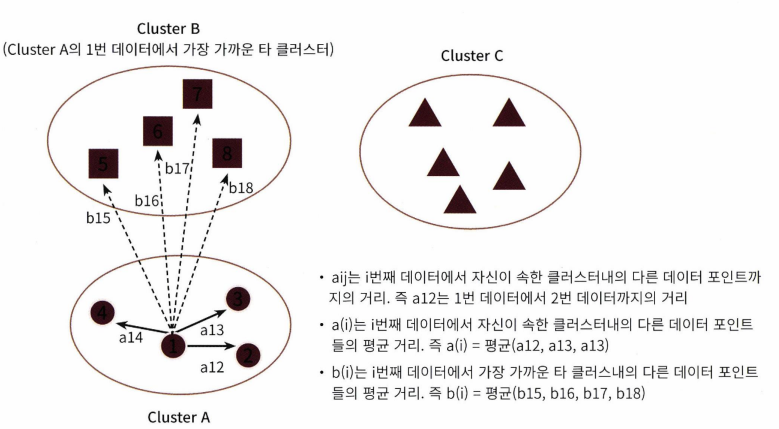


- 특정 데이터 포인트의 실루엣 계수 값은 해당 데이터 포인트와 같은 군집 내에 있는 다른 데이터 포인트와의 거리를 평균한 값 a(i), 해당 포인트가 속하지 않은 군집 중 가장 가까운 군집과의 평균거리 b(i)를 기반으로 계산된다.
- 두 군집 간의 거리가 얼마나 떨어져 있는가의 값은 b(i)-a(i)이며 이 값을 정규화하기 위해 MAX(a(i), b(i)) 값으로 나눈다.

$$ s(i) = \frac{b(i) - a(i)}{\max\left(a(i),\ b(i)\right)}$$

- 실루엣 계수는 -1에서 1 사이의 값을 가진다.
  - s(i)=1 : 인접 군집과의 거리가 멀다
  - s(i)=0 : 인접 군집과의 거리가 가깝다.
  - s(i)=−1 : 군집화가 제대로 이루어지지 않았다.

- 사이킷런은 실루엣 분석을 위해 제공되는 메소드  
  - sklearn.metrics모듈의 silhouette_samples는 각 데이터 포인트마다의 실루엣 계수를 반환하고, silhouette_score는 전체 실루엣 계수의 평균을 반환한다.

  - silhouette_samples()


| 항목               | 설명                  |
| ----------------|------------------------------------------------|
| **함수명**   | `silhouette_samples(X, labels, metric='euclidean')` |
| **주요 목적**   | 각 데이터 포인트에 대한 **개별 실루엣 계수**(s(i)) 반환|
| **입력값 - X** | 데이터 배열 (형태: `[n_samples, n_features]`)   |
| **입력값 - labels** | 군집 레이블 배열 (각 샘플에 대한 클러스터 번호)  |
| **metric**       | 거리 계산 방식 (예: `'euclidean'`, `'manhattan'`, `'cosine'`) |
| **반환값**  | 배열 형태의 실루엣 계수 (shape: `[n_samples]`)  |
| **값의 범위**  | `-1 ~ +1` (값이 클수록 좋은 클러스터링)  |
| **주요 활용**  | 클러스터별 실루엣 평균<br> 이상치 탐지<br> 시각화용    |
| **함수 위치**  | `from sklearn.metrics import silhouette_samples`       |


- silhouette_score()

| 항목               | 내용             |
| ---------------- | ------------------------------------------------------ |
| **함수명**   | `silhouette_score(X, labels, metric='euclidean', **kwargs)`  |
| **주요 목적**| 클러스터링 결과의 응집도(cohesion)와 분리도(separation) 평가 |
| **입력값 - X**  | 데이터 (형태: 배열, \[n\_samples, n\_features])    |
| **입력값 - labels** | 각 샘플의 클러스터 라벨 (예: \[0, 0, 1, 2,1, ...]) |
| **metric**  | 거리 측정 방식 (기본값: `'euclidean'`, 예: `'manhattan'`, `'cosine'` 등) |
| **반환값**   | 실루엣 계수 (float), 범위: `-1 ~ +1`     |
| **값의 해석**  | +1: 잘 분리됨<br> 0: 경계에 위치<br> -1: 잘못 군집됨    |
| **적용 조건**  | 클러스터가 2개 이상이어야 함 (`ValueError` 발생 가능)   |
| **관련 함수** | `silhouette_samples()` → 각 샘플의 실루엣 계수 반환  |

- 좋은 군집화가 되는 기준 조건  
 ① 전체 실루엣 계수의 평균값, 즉 사이킷런의 silhouette_score( )값은 0 ~ 1사이의 값을 가지며, 1에 가까울 수록 좋다.    
 ② 하지만 전체 실루엣 계수의 평균값과 더불어 개별 군집의 평균값이 편차가 크지 않아야 한다. 즉, 개별 군집의 실루엣 계수 평균값이 전체 실루엣 계수의 평균값에서 크게 벗어나지 않는 것이 중요하다. 만약 저체 실루엣 계수의 평균값은 높지만, 특정ㅇ 군집의 실루엣 계수 평균값만 유난히 높고 다른 군집들의 실루엣 계수 평균값은 낮으면 좋은 군집화 조건이 아니다.

KMeans Silhouette Score: 0.3447344346611054
KMeans Adjusted Rand Index: 0.676504895633523


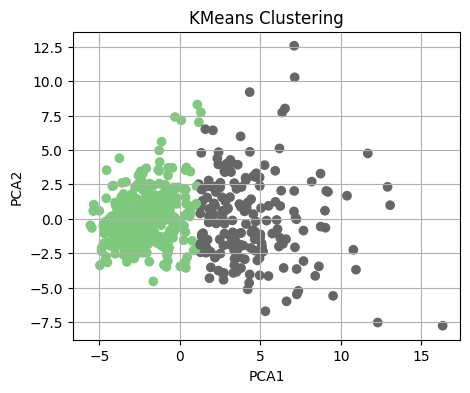

In [ ]:
kmeans_labels = kmeans.fit_predict(X_scaled)
#print(kmeans_labels)

# 평가
print("KMeans Silhouette Score:", silhouette_score(X_scaled, kmeans_labels))
print("KMeans Adjusted Rand Index:", adjusted_rand_score(y, kmeans_labels))

# 시각화
plt.figure(figsize=(5,4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='Accent')
plt.title("KMeans Clustering")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.grid(True)
plt.show()

전체소스

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score

# 데이터 불러오기
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 정답 라벨 (평가용)

# 데이터 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 시각화를 위한 차원 축소 (2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(X_pca.shape)


kmeans = KMeans(n_clusters=2, random_state=0)
kmeans_labels = kmeans.fit_predict(X_scaled)

# 평가
print("KMeans Silhouette Score:", silhouette_score(X_scaled, kmeans_labels))
print("KMeans Adjusted Rand Index:", adjusted_rand_score(y, kmeans_labels))

# 시각화
plt.figure(figsize=(5,4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='Accent')
plt.title("KMeans Clustering")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.grid(True)
plt.show()


# 4. 군집 개수 최적화 방법

[n_clusters 파라미터]

- k-평균 알고리즘의 단점 중 하나는 클러스터 개수를 사전에 지정해야 한다는 점
- 엘보우(elbow) 방법: 적절한 클러스터 개수(최적의 k)를 찾기 위한 대표적인 방법
  - 이너셔(inertia): k-평균 알고리즘은 클러스터 중심과 클러스터에 속한 샘플 사이 거리의 제곱 합
  - 이너셔는 클러스터에 속한 샘플이 얼마나 가깝게 모여 있는지를 나타내는 값

  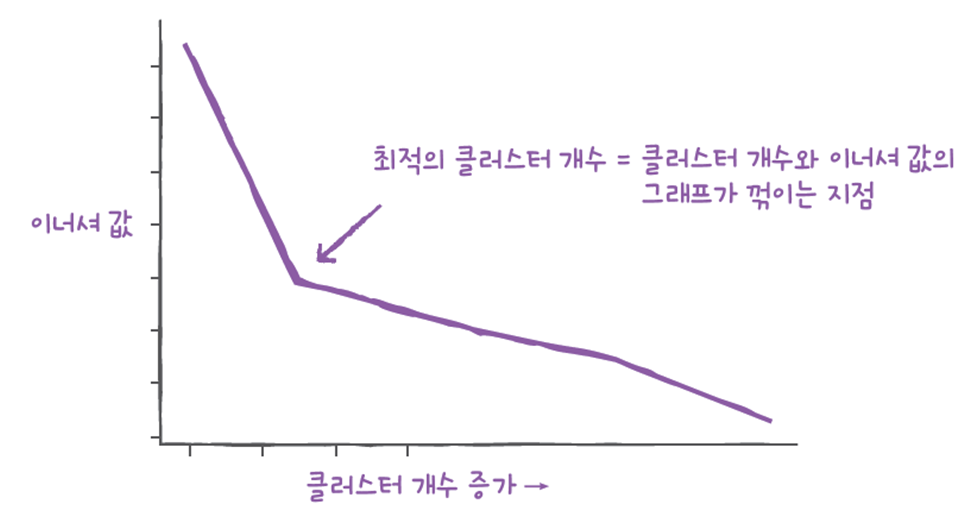

- inertia_란?


| 항목    | 설명                                                                    |   |            |   |                                                          |
| ----- | --------------------------------------------------------------------- | - | ---------- | - | -------------------------------------------------------- |
| 정의    | 모든 데이터 포인트가 자신의 클러스터 중심까지 가지는 거리의 제곱합 (Within-cluster sum of squares) |   |            |   |                                                          |
| 계산 방식 | $$ \text{Inertia} = \sum\_{i=1}^{k} \sum\_{x \in C\_i}              |   | x - \mu\_i |   | ^2 $$ <br> (여기서 $C_i$는 i번째 클러스터, $\mu_i$는 i번째 클러스터 중심) |
| 목적    | 클러스터링 결과의 응집도 측정. 값이 작을수록 클러스터 내부가 잘 모여 있다는 의미                        |   |            |   |                                                          |
| 사용 예시 | **엘보우 방법(Elbow Method)**: 최적의 k값을 찾기 위해 inertia의 급격한 감소가 멈추는 지점을 확인   |   |            |   |                                                          |
| 주의 사항 | inertia는 클러스터 수가 많아질수록 작아지므로 단독으로 최적 k를 결정할 수는 없음                     |   |            |   |                                                          |


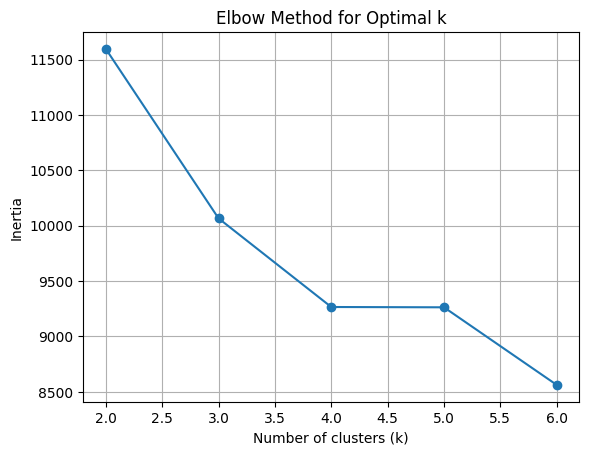

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    #km.fit_predict(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2, 7), inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.show()

1. 전체 분석 흐름

| 단계                    | 설명                             |
| --------------------- | ------------------------------ |
| ① 데이터 로드              | `load_breast_cancer()` 데이터셋 로드 |
| ② 전처리                 | `StandardScaler`로 스케일링         |
| ③ KMeans 실행           | `k=2~10`까지 클러스터링 수행            |
| ④ Inertia 시각화         | Elbow Method로 최적 k 탐색          |
| ⑤ Silhouette Score 분석 | 클러스터 품질 비교 및 보조 판단             |


 2. 코드 KMeans + Inertia + Silhouette Score

range(2, 11)
[np.float64(0.3447344346611054), np.float64(0.3151862330494096), np.float64(0.274157742034422), np.float64(0.16454819399495385), np.float64(0.1450578794997139), np.float64(0.1469508140067517), np.float64(0.16185657051384186), np.float64(0.1439495585582379), np.float64(0.14706722381698448)]


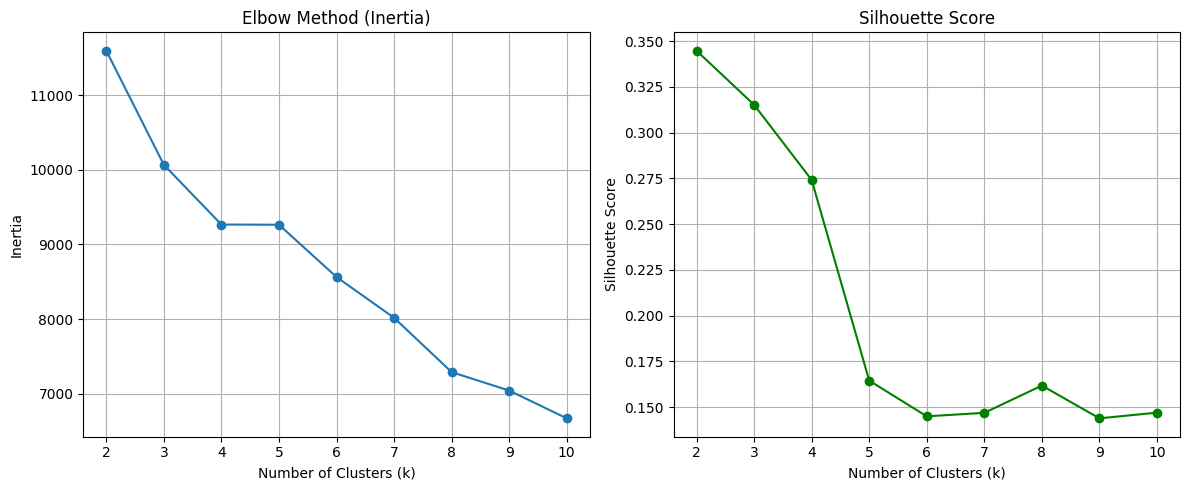

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# ① 데이터 로드 및 전처리
data = load_breast_cancer()
X = data.data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ② 클러스터 개수별 inertia 및 실루엣 점수 저장
inertia = []
silhouette = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)  # kmeans.fit(X_scaled)  kmeans.labels_

    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

# ③ 시각화
plt.figure(figsize=(12, 5))

# Elbow Method
plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method (Inertia)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)

# Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette, marker='o', color='green')
print(K_range)
print(silhouette)
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()


# 3. Inertia와 Silhouette Score 해석 방법

| 척도                   | 의미                         | 해석 방법                                                                   |
| -------------------- | -------------------------- | ----------------------------------------------------------------------- |
| **Inertia**          | 군집 내 거리의 제곱합               | 값이 작을수록 군집 내부 응집도가 높음. 하지만 **k가 커질수록 무조건 감소**하므로 단독으로 최적 k 판단은 어려움      |
| **Silhouette Score** | -1\~1 범위<br>각 샘플의 클러스터 적합도 | 값이 **1에 가까울수록 좋음**. 클러스터 간 분리가 잘 되고 내부 응집도도 높음을 의미함. 보통 **0.5 이상이면 양호** |


# 4. 결과 해석 예시
- Elbow Method 그래프에서 inertia 감소폭이 뚜렷이 꺾이는 지점(knee point) → 최적의 k 후보
- Silhouette Score에서 가장 높은 점수의 k → 군집 품질이 가장 좋은 k

| 예시 판단                                                |
| ---------------------------------------------------- |
| inertia: k=3 이후부터 감소폭이 둔화 → k=2 또는 3 후보              |
| silhouette: k=2에서 0.345, k=3에서 0.315 → k=2가 더 좋은 분리 품질 |
| ★ 최적 k = **2** 가 유력                                 |


In [ ]:
from sklearn.metrics import silhouette_samples, silhouette_score

def visualize_silhouette(X, labels, title="Silhouette Plot"):
    """
    Silhouette 시각화를 위한 커스텀 함수

    Parameters:
    - X: 입력 데이터 (numpy 배열 또는 DataFrame)
    - labels: 클러스터링 결과 레이블 (1D 배열)
    - title: 그래프 제목 (기본값: "Silhouette Plot")
    """
    # 샘플별 실루엣 계수
    sil_values = silhouette_samples(X, labels)
    avg_score = silhouette_score(X, labels)
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels)

    fig, ax = plt.subplots(figsize=(8, 5))
    y_lower = 10

    for i in unique_labels:
        ith_sil_values = sil_values[labels == i]
        ith_sil_values.sort()
        size = ith_sil_values.shape[0]
        y_upper = y_lower + size

        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil_values, label=f"Cluster {i}")
        ax.text(-0.05, y_lower + 0.5 * size, str(i))
        y_lower = y_upper + 10

    ax.axvline(x=avg_score, color="red", linestyle="--", label=f"Avg = {avg_score:.2f}")
    ax.set_xlabel("Silhouette Coefficient")
    ax.set_ylabel("Samples")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

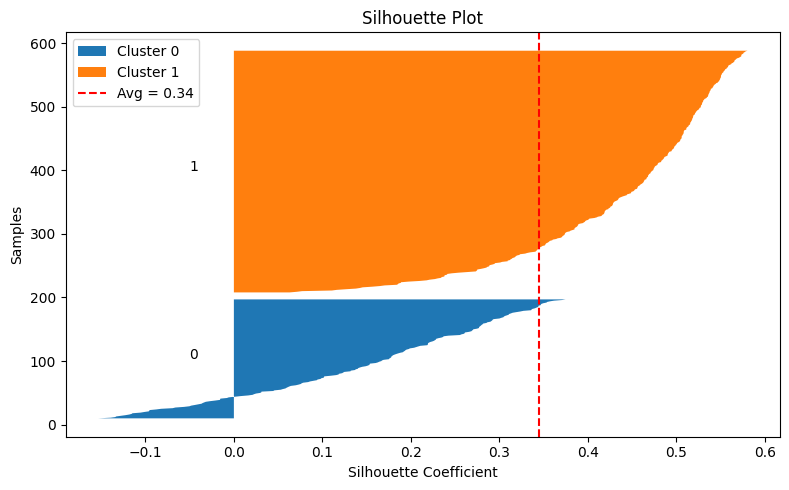

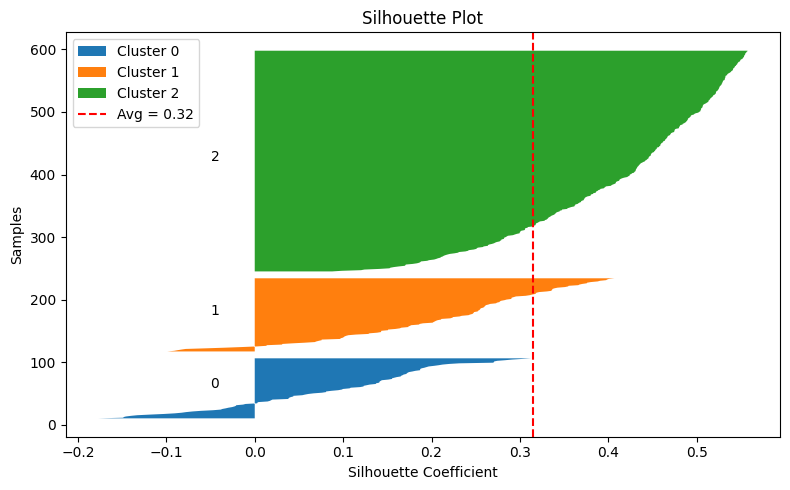

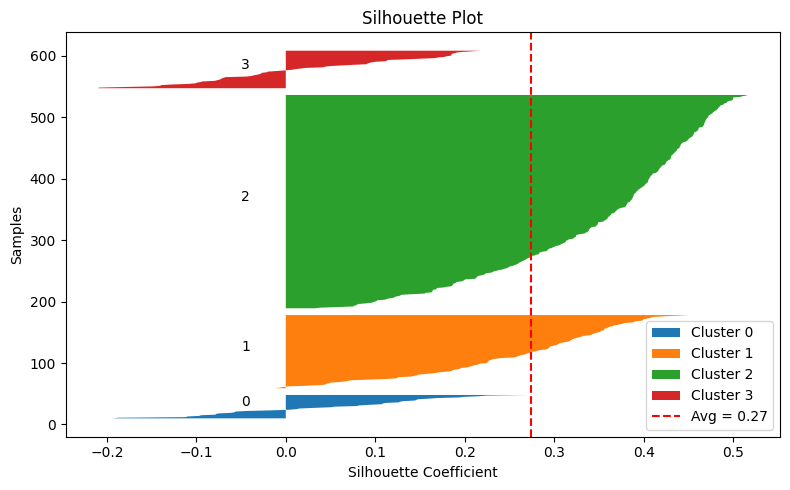

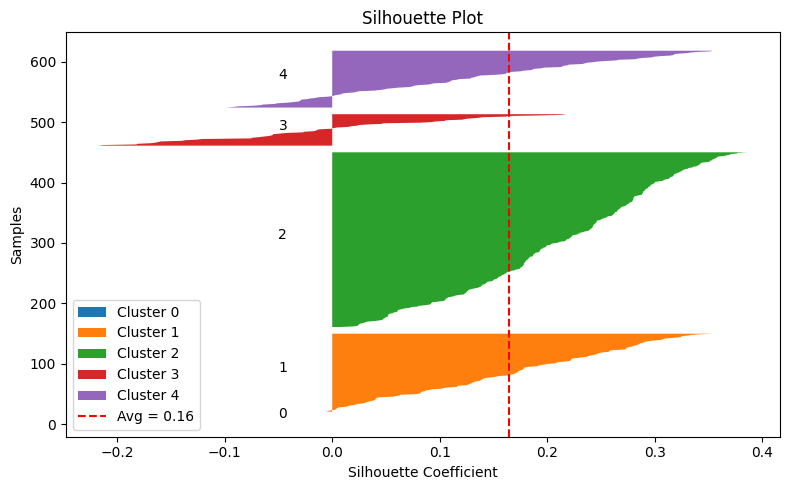

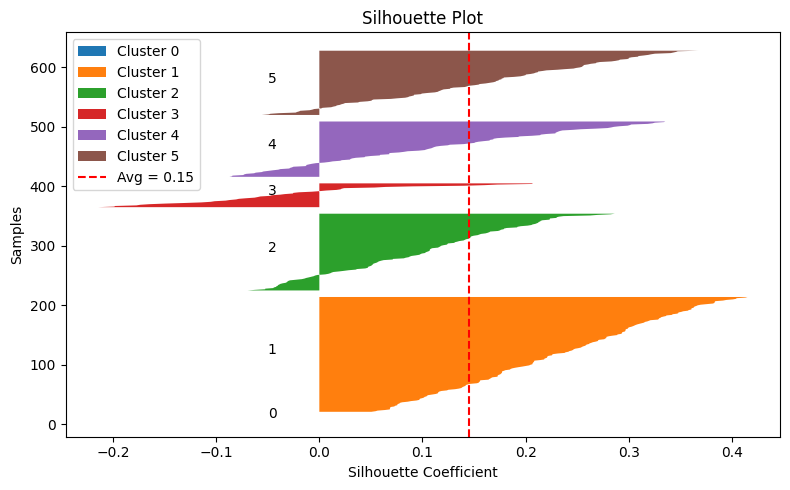

In [ ]:

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 데이터 로드 및 정규화
data = load_breast_cancer()
X = data.data
X_scaled = StandardScaler().fit_transform(X)

# # KMeans 클러스터링
for i in range(2, 7):
    model = KMeans(n_clusters=i, random_state=42)
    labels = model.fit_predict(X_scaled)

    # 올바른 호출
    visualize_silhouette(X_scaled, labels)
